<a href="https://colab.research.google.com/github/Dr-Isam-ALJAWARNEH/fds-project-geodevelopers/blob/main/Simple_code_draft_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install required packages

In [1]:
!pip install pygeohash geopandas datascience --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.5 MB/s eta 0:00:00


Import all necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pygeohash as gh
import networkx as nx
from sklearn.cluster import KMeans
from scipy.spatial import distance_matrix


Load all 19 CSV parts into a single DataFrame

In [3]:
Chicago = pd.DataFrame()

for i in range(1, 20):
    file_link = f'https://raw.githubusercontent.com/IsamAljawarneh/datasets/refs/heads/master/data/Chicago/AQ_data/chicago_eclipse_data_part_{i}.csv'
    try:
        temp_df = pd.read_csv(file_link)
        Chicago = pd.concat([Chicago, temp_df], ignore_index=True)
    except Exception as e:
        print(f"Failed to load part {i}: {e}")

In [4]:
Chicago

,City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:03:00,5.561094,NaN,NaN,NaN,0.123580,27.383499,55.128479,4.237187,93.964844,-76.0
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:08:10,6.633914,NaN,NaN,NaN,0.132103,27.079086,55.059814,4.236094,93.964844,-81.0
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:13:20,4.068707,NaN,NaN,NaN,0.131126,27.079086,55.035400,4.236406,93.964844,-80.0
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:18:30,6.351702,NaN,NaN,NaN,0.138784,26.945572,54.632568,4.236094,93.863281,-82.0
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:23:40,9.574065,NaN,NaN,NaN,0.413070,26.828079,53.907776,4.235938,93.863281,-81.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2461084,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:29:48,4.479115,10.72,34.66,12.51,0.413648,22.817307,73.245239,4.176250,89.785156,-62.0
2461085,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:34:58,6.322502,14.89,34.71,6.35,0.656208,22.713165,73.222351,4.186875,89.785156,-61.0
2461086,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:40:08,9.796841,13.51,36.71,2.62,0.336273,22.659760,73.472595,4.186250,89.683594,-60.0
2461087,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:45:17,5.173977,11.20,34.33,3.53,0.372924,22.526245,73.468018,4.186250,89.683594,-61.0


Plot initial scatter to check invalid or spread data points

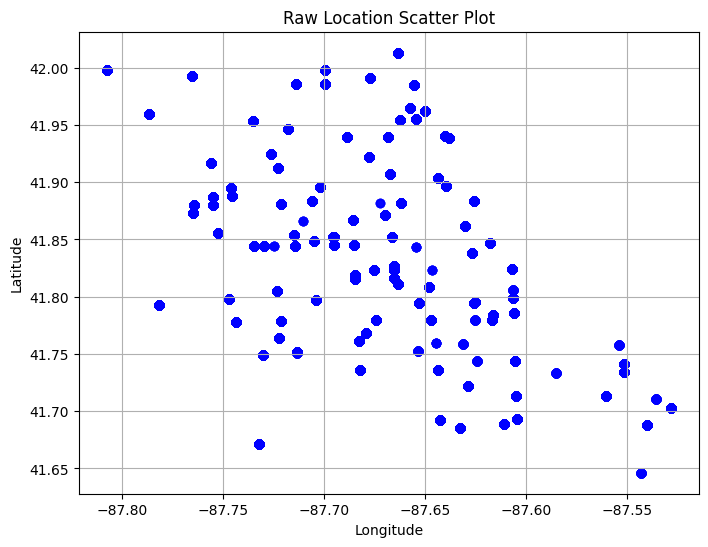

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(Chicago['Longitude'], Chicago['Latitude'], alpha=0.5, c='blue')
plt.title("Raw Location Scatter Plot")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

Clean data: remove NaNs and PM25 outliers

In [6]:
df = Chicago[['Latitude', 'Longitude', 'PM25']].dropna().reset_index(drop=True)

Remove outliers using IQR (Interquartile Range)

In [7]:
Q1 = df['PM25'].quantile(0.25)
Q3 = df['PM25'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['PM25'] >= Q1 - 1.5 * IQR) & (df['PM25'] <= Q3 + 1.5 * IQR)].reset_index(drop=True)

Generate Geohash codes with precision 6

In [8]:
Geohash_precision = 6
df['geohash'] = df.apply(lambda row: gh.encode(row['Latitude'], row['Longitude'], precision=Geohash_precision), axis=1)


Plot Geohash Grid Map using average Lat/Lon of each code

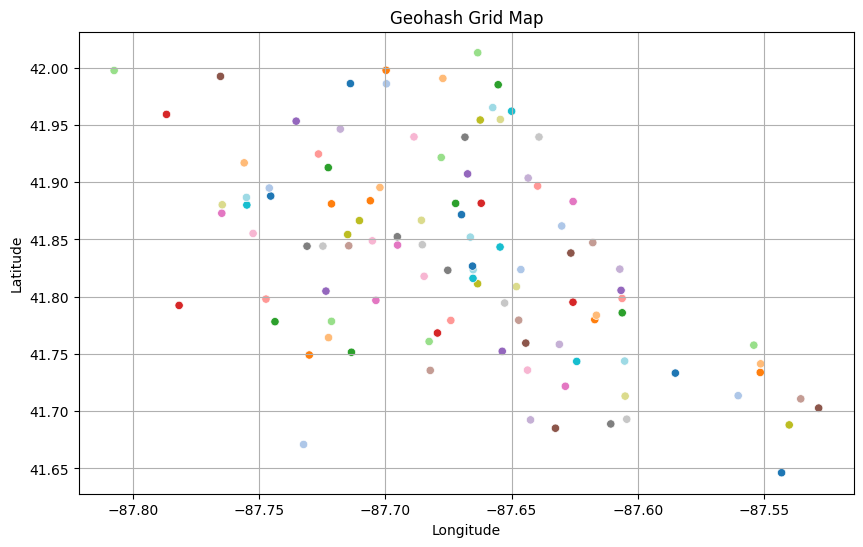

In [9]:
geo_group = df.groupby('geohash')[['Latitude', 'Longitude']].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=geo_group, x='Longitude', y='Latitude', hue='geohash', palette='tab20', legend=False)
plt.title("Geohash Grid Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

Apply KMeans clustering with 9 clusters (paths)

In [10]:
kmeans = KMeans(n_clusters=9, random_state=0).fit(df[['Latitude', 'Longitude']])
df['cluster'] = kmeans.labels_
centroids = kmeans.cluster_centers_


Construct MST (Minimum Spanning Tree) using cluster centroids

In [14]:
dist_matrix = distance_matrix(centroids, centroids)
G = nx.Graph()

# Add weighted edges (distance as weight)
for i in range(len(centroids)):
    for j in range(i + 1, len(centroids)):
        G.add_edge(i, j, weight=dist_matrix[i][j])

# Generate MST using Prim's algorithm
mst = nx.minimum_spanning_tree(G)

Identify 2 most polluted clusters and find best MST path using A*

In [15]:
centroid_pm = [df[df['cluster'] == i]['PM25'].mean() for i in range(9)]
top_two = np.argsort(centroid_pm)[-2:]  # Get top 2 by PM25

def heuristic(a, b):
    return np.linalg.norm(centroids[a] - centroids[b])

best_path = nx.astar_path(mst, source=top_two[0], target=top_two[1], heuristic=heuristic, weight='weight')


Visualize MST with A* path between top 2 polluted clusters

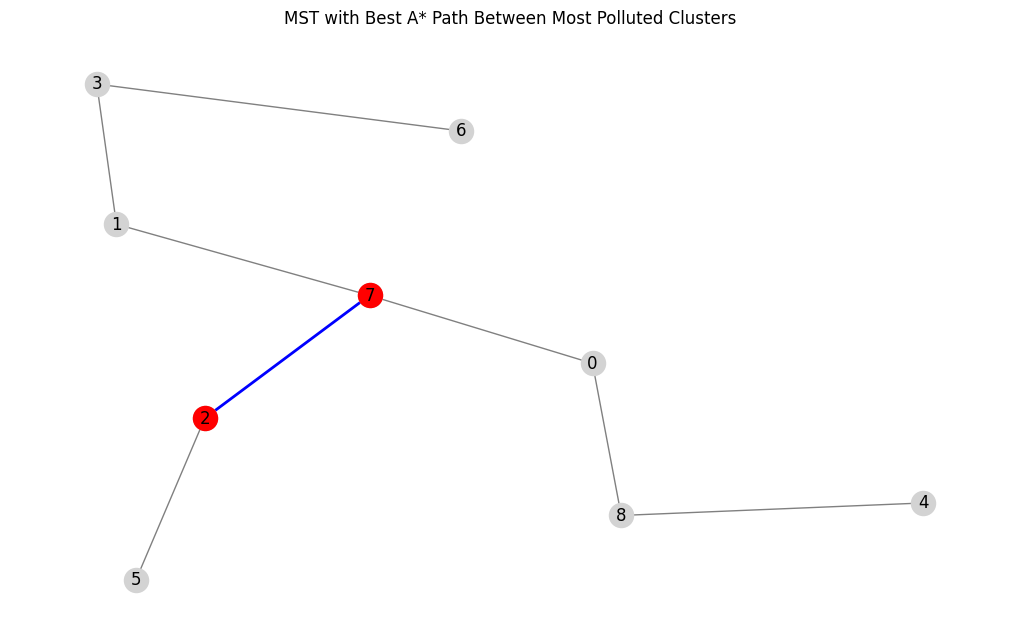

In [16]:
# Convert to (lon, lat) format for plotting
pos = {i: (centroids[i][1], centroids[i][0]) for i in range(len(centroids))}

plt.figure(figsize=(10, 6))
nx.draw(mst, pos, with_labels=True, node_color='lightgray', edge_color='gray')
nx.draw_networkx_nodes(mst, pos, nodelist=best_path, node_color='red')
nx.draw_networkx_edges(mst, pos, edgelist=list(zip(best_path, best_path[1:])), edge_color='blue', width=2)
plt.title("MST with Best A* Path Between Most Polluted Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()